## Aim 

Compute the betweeness centrality for the entire Bangalore.

## Reading in the Python libraries

In [1]:
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import momepy
import numpy as np
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
import rasterio
from rasterio.features import rasterize
from scipy.stats import linregress, pearsonr
from tqdm import tqdm

In [ ]:
cloud_project = 'FILL IN YOUR CLOUD PROJECT'

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

## Loading the data

In [3]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


Loading the ward data:

In [4]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [5]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [6]:
G = ox.io.load_graphml(path_graphml)

## Selecting the Bellandur area

Looking at the map, the Bellandur area consists of three wards:

- 46 - Yamalur
- 47 - Bellanduru
- 49 - Shivanasamudra ward

Selecting the wards:

In [7]:
bellandur = df[df["ward_name"].isin(["46 - Yamalur", "47 - Bellanduru", "49 - Shivanasamudra Ward"])]
bellandur

,ward_id,ward_name,Corporatio,geometry
6,46,46 - Yamalur,East,"POLYGON ((77.69548 12.94599, 77.6951 12.9459, ..."
203,47,47 - Bellanduru,East,"POLYGON ((77.66804 12.93124, 77.66893 12.93099..."
208,49,49 - Shivanasamudra Ward,East,"POLYGON ((77.66498 12.9206, 77.66509 12.92072,..."


<Axes: >

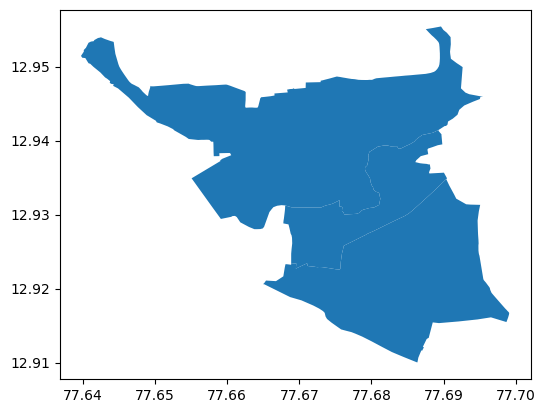

In [8]:
bellandur.plot()

In [9]:
## Save this
bellandur_wards_path = PROCESSED_DIR / "bellandur.shp"
bellandur.to_file(bellandur_wards_path)

<Axes: >

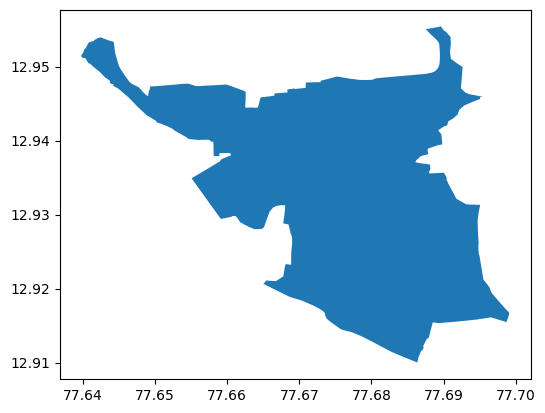

In [10]:
# Merge these wards together
bellandur_dissolved = bellandur.dissolve()
bellandur_dissolved.plot()

In [11]:
## Save this
dissolved_bang_path = PROCESSED_DIR / "bellandur_dissolved.shp"
bellandur_dissolved.to_file(dissolved_bang_path)

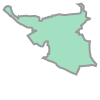

In [12]:
bellandur_geometry = bellandur_dissolved.geometry.iloc[0]
bellandur_geometry

In [13]:
## Extract the network:
G_bellandur = ox.truncate.truncate_graph_polygon(G, bellandur_geometry)

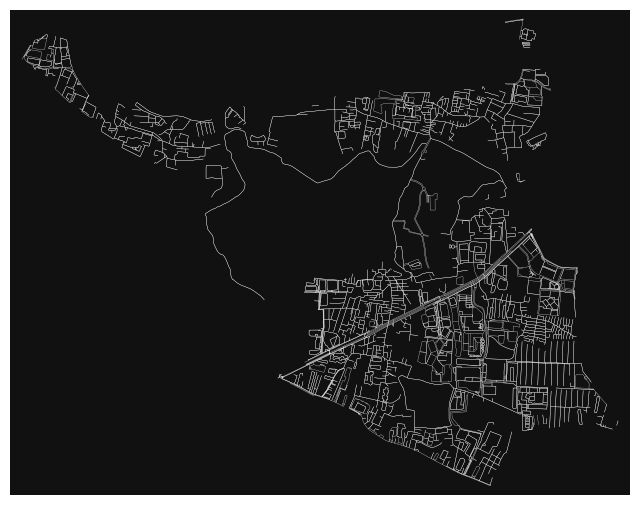

In [14]:
fig, ax = ox.plot_graph(G_bellandur, node_size=0, edge_color="w", edge_linewidth=0.2)

In [15]:
streets_graph = ox.projection.project_graph(G_bellandur)


In [16]:
edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

In [17]:
## https://docs.momepy.org/en/latest/api/momepy.betweenness_centrality.html
## https://docs.momepy.org/en/v0.7.2/user_guide/graph/centrality.html

In [18]:
streets_graph = ox.projection.project_graph(G_bellandur)

In [19]:
edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

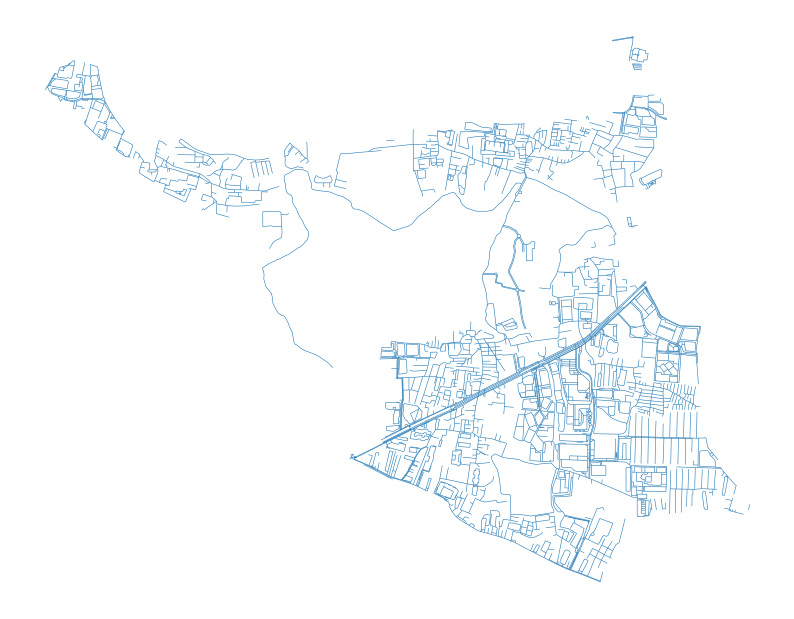

In [20]:
f, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=0.4)
ax.set_axis_off()
plt.show()

In [21]:
primal = momepy.gdf_to_nx(edges, approach="primal")

In [22]:
primal = momepy.betweenness_centrality(primal, name='betweenness_metric_e', mode='edges', weight='mm_len')

In [23]:
primal_gdf = momepy.nx_to_gdf(primal, points=False)

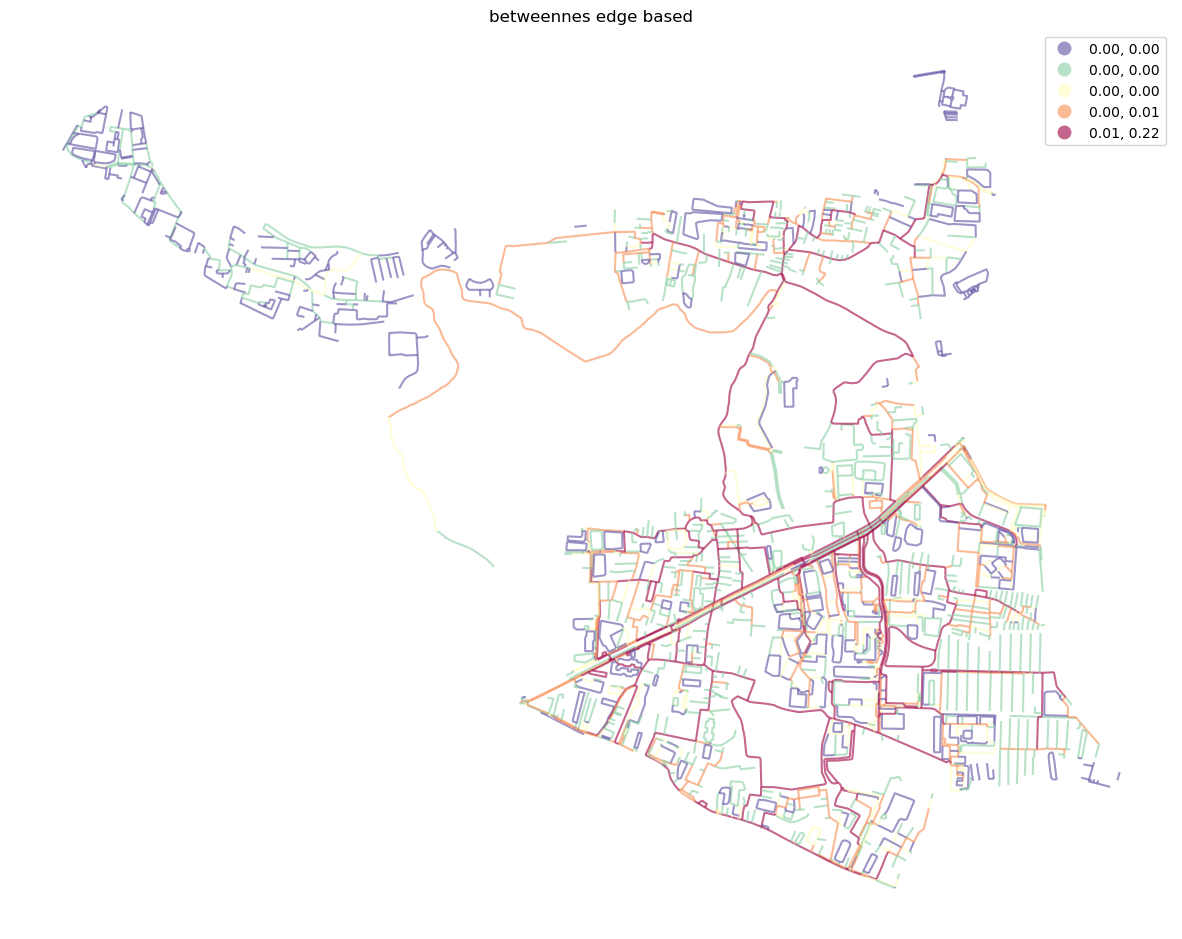

In [24]:
f, ax = plt.subplots(figsize=(15, 15))
primal_gdf.plot(ax=ax, column='betweenness_metric_e', cmap='Spectral_r', scheme='quantiles', alpha=0.6, legend = True)
ax.set_axis_off()
ax.set_title('betweennes edge based')
plt.show()

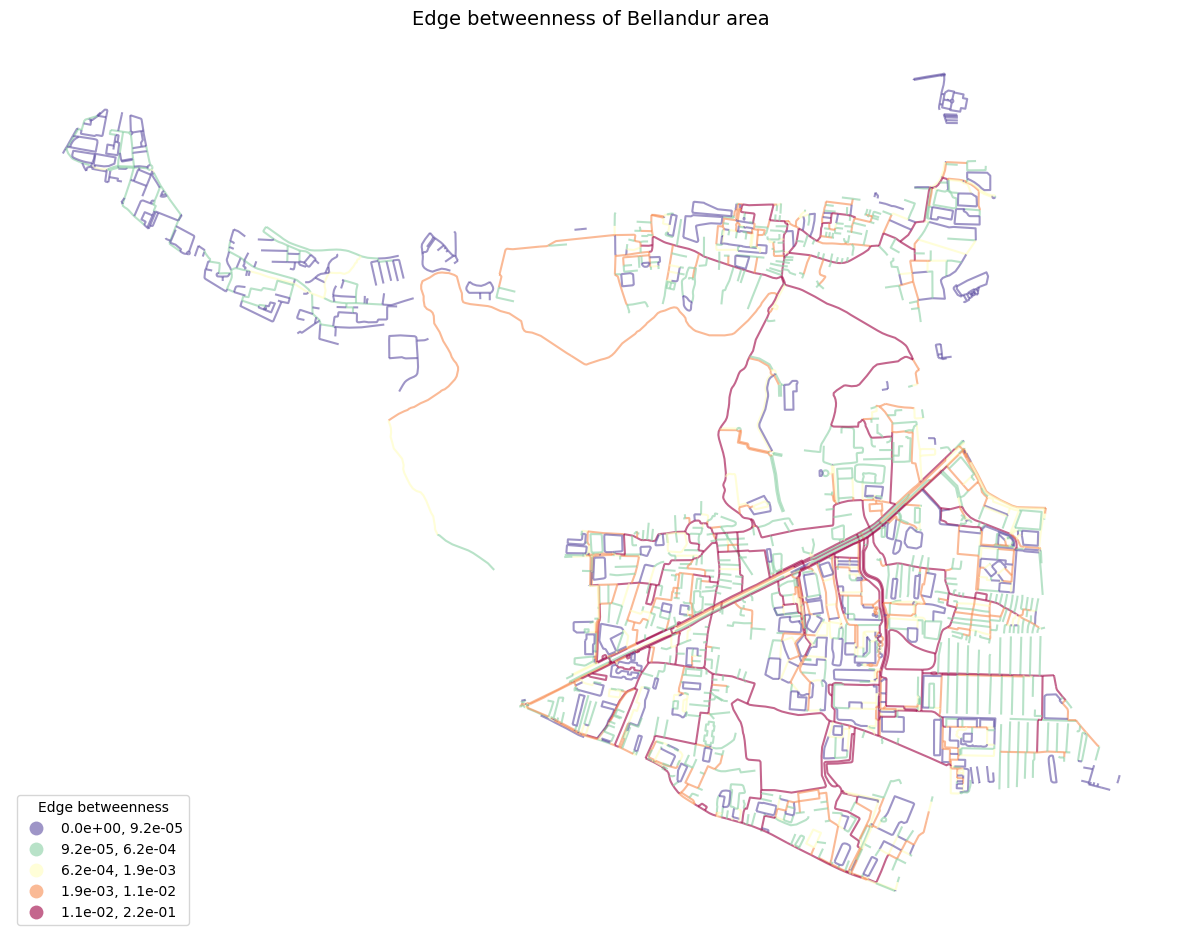

In [25]:
fig_path = IMAGES_DIR / 'betweeness_all_roads_bellandur.png'
f, ax = plt.subplots(figsize=(15, 15))

primal_gdf.plot(
    ax=ax,
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    k=5,
    legend=True,
    alpha=0.6,
    legend_kwds={
        "title": "Edge betweenness",
        "fmt": "{:.1e}",
        "loc": "lower left"
    }
)

ax.set_axis_off()
ax.set_title("Edge betweenness of Bellandur area", fontsize=14)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [26]:
primal_gdf.shape

(3593, 21)

In [27]:
primal_gdf.head()

,osmid,highway,lanes,oneway,reversed,length,from,to,geometry,maxspeed,...,ref,access,junction,bridge,service,est_width,tunnel,width,mm_len,betweenness_metric_e
0,240694321,tertiary,2,False,False,29.740066,9828511712,262268684,"LINESTRING (789222.649 1429875.406, 789242.575...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.694540,6.180161e-04
1,1109938619,footway,NaN,False,True,17.767792,11955000963,9828511712,"LINESTRING (789216.342 1429891.946, 789222.649...",NaN,...,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,17.702181,6.180161e-04
2,240694321,tertiary,2,False,False,12.460330,9828511707,9828511712,"LINESTRING (789215.906 1429864.974, 789220.889...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.428897,2.446455e-03
3,"[1071044451, 1109938619]",footway,NaN,False,"[False, True]",35.608295,9828511701,9828511712,"LINESTRING (789248.244 1429874.466, 789241.122...",NaN,...,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,35.582517,4.152337e-03
4,"[1240374873, 1109938618]",trunk,"[3, 5]",True,False,26.759767,11955000963,262268684,"LINESTRING (789216.342 1429891.946, 789230.62 ...",60,...,NH44;NH48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.804650,2.613176e-07


In [28]:
# Save to gpkg file (can view in QGIS if needed);
primal_gdf.crs

<Projected CRS: EPSG:32643>
Name: WGS 84 / UTM zone 43N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°E and 78°E, northern hemisphere between equator and 84°N, onshore and offshore. China. India. Kazakhstan. Kyrgyzstan. Maldives. Pakistan. Russian Federation. Tajikistan.
- bounds: (72.0, 0.0, 78.0, 84.0)
Coordinate Operation:
- name: UTM zone 43N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
## Convert it back to epsg 4326
primal_gdf_reproj = primal_gdf.to_crs(4326)

In [30]:
## Save as a gpkg to read into QGIS:
path_betweeness = PROCESSED_DIR / 'betweeness.gpkg'
primal_gdf_reproj.to_file(path_betweeness)

## Land Surface temperature

In this script, the band 10 of Landsat 8 is used to compute the Land Surface Temperature. 

In [31]:
print(dissolved_bang_path)
print(bellandur_wards_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bellandur_dissolved.shp
C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bellandur.shp


In [32]:
# https://geemap.org/notebooks/10_shapefiles/ 
# Convert to something geemap can understand
bellandur_fc = geemap.shp_to_ee(dissolved_bang_path)

In [33]:
bellandur_wards = geemap.shp_to_ee(bellandur_wards_path)

In [34]:
Map = geemap.Map()
Map.centerObject(bellandur_fc, zoom=13)
Map # Uncomment if you want to see the map. 
## Otherwise you can wait till later Maps as all layers are in them

Map(center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position', 'transparent_b…

In [35]:
## Add the ward data
image = ee.Image().paint(bellandur_wards, 0, 2)
Map.addLayer(image, {'palette': 'red'}, "Bellandur wards")
Map

Map(bottom=972887.0, center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position…

In [36]:
# Map.addLayer(bellandur_wards, {'color': 'red'}, 'Bellandur three wards')
# Map

In [37]:
Map.addLayer(bellandur_fc, {}, 'Bellandur outline')
Map

Map(bottom=972887.0, center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position…

In [38]:
colThsummer = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
.filterBounds(bellandur_fc) \
.filterDate('2024-01-01', '2025-11-01') \
.filter(ee.Filter.calendarRange(3, 5, 'month'))

In [39]:
## colThsummer

In [40]:
def maskL8sr(image):
    ## Code obtained from:
    ## https://courses.spatialthoughts.com/end-to-end-gee-supplement.html#derive-lst-from-landsat-images 
    qaMask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturationMask = image.select('QA_RADSAT').eq(0)

    # Scaling factors
    opticalBands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermalBands = image.select('ST_B.*').multiply(0.00341802).add(149.0)

    # Replace the original bands with the scaled ones and apply the masks.
    return image.addBands(opticalBands, None, True) \
    .addBands(thermalBands, None, True) \
    .updateMask(qaMask) \
    .updateMask(saturationMask)

In [41]:
colThsummer = colThsummer.map(maskL8sr)

In [42]:
## colThsummer

In [43]:
imageThsummer = colThsummer.median()

In [44]:
## imageThsummer

In [45]:
image_clipped = imageThsummer.clip(bellandur_fc)

visualisation = {
  'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 
  'min': 0,
  'max': 0.5,
  'gamma': [0.95, 1.1, 1]
}

Map.addLayer(image_clipped, visualisation, 'True Color Composite Bangalore')

Map

Map(bottom=972887.0, center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position…

In [46]:
thermalsummer = imageThsummer.select('ST_B10') \
.clip(bellandur_fc) \

Map.addLayer(thermalsummer, {
"min": 300,
"max": 320,
"palette": ['blue', 'white', 'red']},'Landsat_BT')

Map

Map(bottom=972887.0, center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position…

In [47]:
## Convert to Celsius
thermal_summer_c = (
thermalsummer
.clip(bellandur_fc)
.subtract(273.15)
.rename('LST_C')
)

In [48]:
Map.addLayer(thermal_summer_c, {
    "min": 35,
    "max": 42,
    "palette": ['blue', 'white', 'red'],
},
'LST_Landsat')

vis_params = {'min': 35, 'max': 42, 'palette': ['blue', 'white', 'red']}
Map.add_colorbar(vis_params, label='Land Surface Temperature (°C)',position= 'bottomright')
Map

Map(bottom=972887.0, center=[12.93310848174732, 77.67603626828884], controls=(WidgetControl(options=['position…

Export this map (for opening in QGIS):

In [49]:
edges

osmid      highway   lanes  \
u           v           key                                                  
262268684   9828511712  0                   240694321     tertiary       2   
            11955000963 0    [1240374873, 1109938618]        trunk  [3, 5]   
9828511712  11955000963 0                  1109938619      footway     NaN   
            9828511707  0                   240694321     tertiary       2   
            9828511701  0    [1071044451, 1109938619]      footway     NaN   
...                                               ...          ...     ...   
13142029208 13142029212 0                  1429653266      footway     NaN   
13142028800 13142028800 0                  1429653249      service     NaN   
13142029196 13142029198 0                  1429653263  residential     NaN   
13142029198 13142029209 0                  1071287741  residential     NaN   
13142029203 13142029203 0                  1429653264      service     NaN   

                             oneway       reversed      length         from  \
u           v           key                                                   
262268684   9828511712  0     False          False   29.740066   9828511712   
            11955000963 0      True          False   26.759767  11955000963   
9828511712  11955000963 0     False           True   17.767792  11955000963   
            9828511707  0     False          False   12.460330   9828511707   
            9828511701  0     False  [False, True]   35.608295   9828511701   
...                             ...            ...         ...          ...   
13142029208 13142029212 0     False          False   15.091343  13142029212   
13142028800 13142028800 0     False          False  288.801276  13142028800   
13142029196 13142029198 0     False          False   23.982350  13142029198   
13142029198 13142029209 0      True          False    5.593823  13142029198   
13142029203 13142029203 0     False          False   29.604162  13142029203   

                                      to  \
u           v           key                
262268684   9828511712  0      262268684   
            11955000963 0      262268684   
9828511712  11955000963 0     9828511712   
            9828511707  0     9828511712   
            9828511701  0     9828511712   
...                                  ...   
13142029208 13142029212 0    13142029208   
13142028800 13142028800 0    13142028800   
13142029196 13142029198 0    13142029196   
13142029198 13142029209 0    13142029209   
13142029203 13142029203 0    13142029203   

                                                                      geometry  \
u           v           key                                                      
262268684   9828511712  0    LINESTRING (789222.649 1429875.406, 789242.575...   
            11955000963 0    LINESTRING (789216.342 1429891.946, 789230.62 ...   
9828511712  11955000963 0    LINESTRING (789216.342 1429891.946, 789222.649...   
            9828511707  0    LINESTRING (789215.906 1429864.974, 789220.889...   
            9828511701  0    LINESTRING (789248.244 1429874.466, 789241.122...   
...                                                                        ...   
13142029208 13142029212 0    LINESTRING (790529.895 1432839.438, 790534.83 ...   
13142028800 13142028800 0    LINESTRING (790545.442 1432550.533, 790590.712...   
13142029196 13142029198 0    LINESTRING (790636.984 1432822.548, 790630.631...   
13142029198 13142029209 0    LINESTRING (790636.984 1432822.548, 790637.226...   
13142029203 13142029203 0    LINESTRING (790581.312 1432848.568, 790583.628...   

                            maxspeed             name        ref   access  \
u           v           key                                                 
262268684   9828511712  0        NaN              NaN        NaN      NaN   
            11955000963 0         60  Outer Ring Road  NH44;NH48      NaN   
9828511712  11955000963 0        NaN              NaN    

In [50]:
edges.shape

(3593, 19)

In [51]:
## https://geemap.org/notebooks/11_export_image/#download-an-eeimage
## To view in QGIS:
filepath = PROCESSED_DIR / 'bellandur_lst.tif'
geemap.ee_export_image(
    thermal_summer_c, filename=filepath, 
    scale=30,              
    region= bellandur_fc.geometry(),
    file_per_band=False
)

Generating URL ...
Please wait ...
Data downloaded to C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bellandur_lst.tif


In [52]:
# Read back in the image (you can also convert to a raster):
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [53]:
primal_gdf_reproj.head()

,osmid,highway,lanes,oneway,reversed,length,from,to,geometry,maxspeed,...,ref,access,junction,bridge,service,est_width,tunnel,width,mm_len,betweenness_metric_e
0,240694321,tertiary,2,False,False,29.740066,9828511712,262268684,"LINESTRING (77.66537 12.92074, 77.66556 12.92093)",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.694540,6.180161e-04
1,1109938619,footway,NaN,False,True,17.767792,11955000963,9828511712,"LINESTRING (77.66532 12.92089, 77.66537 12.92074)",NaN,...,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,17.702181,6.180161e-04
2,240694321,tertiary,2,False,False,12.460330,9828511707,9828511712,"LINESTRING (77.66531 12.92064, 77.66536 12.920...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.428897,2.446455e-03
3,"[1071044451, 1109938619]",footway,NaN,False,"[False, True]",35.608295,9828511701,9828511712,"LINESTRING (77.66561 12.92073, 77.66554 12.920...",NaN,...,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,35.582517,4.152337e-03
4,"[1240374873, 1109938618]",trunk,"[3, 5]",True,False,26.759767,11955000963,262268684,"LINESTRING (77.66532 12.92089, 77.66545 12.920...",60,...,NH44;NH48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.804650,2.613176e-07


In [54]:
# Need to fix code a bit here
from rasterio.mask import mask

In [55]:
with rasterio.open(filepath) as src:
    lst_masked, transform = mask(
        src,
        bellandur.geometry,
        crop=True
    )
    lst_masked = lst_masked[0]

In [56]:
lst_masked = lst_masked.astype("float32")
lst_masked[lst_masked == src.nodata] = np.nan

In [57]:
lst_masked[lst_masked <= -9999] = np.nan

In [58]:
cmap = plt.cm.RdYlBu_r.copy()
cmap.set_bad(color=(0, 0, 0, 0))  # transparent


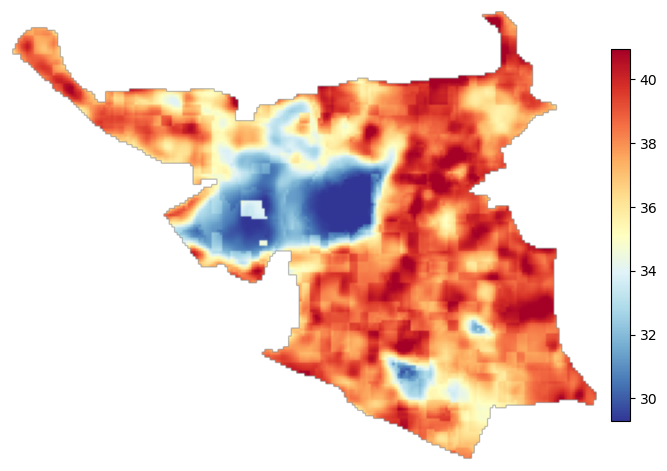

In [59]:
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    lst_masked,
    cmap=cmap,
    vmin=np.nanpercentile(lst_masked, 2),
    vmax=np.nanpercentile(lst_masked, 98),
    origin="upper"
)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
ax.axis("off")

plt.show()


In [60]:
from rasterio.transform import array_bounds

height, width = lst_masked.shape
bounds = array_bounds(height, width, transform)
extent = [bounds[0], bounds[2], bounds[1], bounds[3]]


In [61]:
lst_betweenness_path = IMAGES_DIR / 'lst_betweeness_bellandur.png'

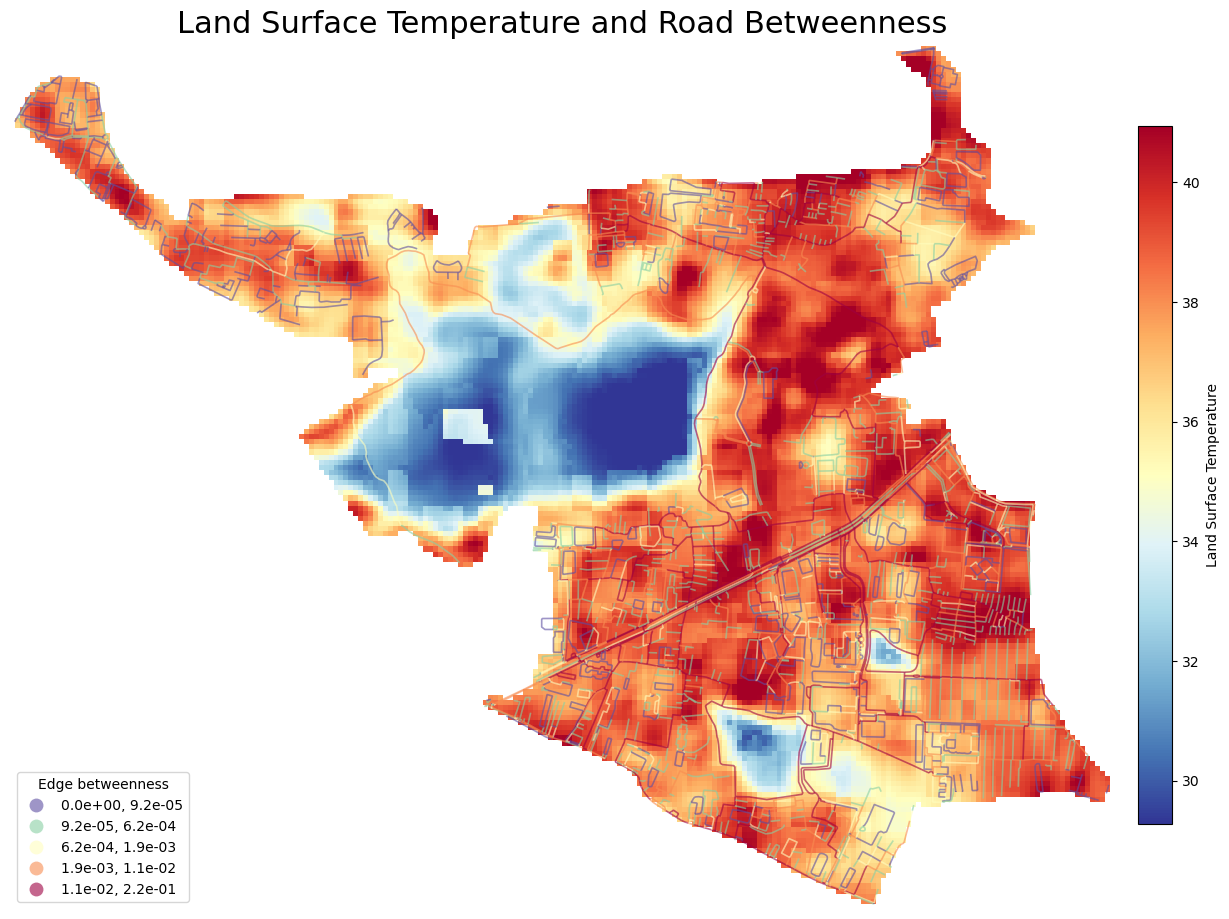

In [62]:
f, ax = plt.subplots(figsize=(15, 15))

im = ax.imshow(
    lst_masked,
    cmap=cmap,
    vmin=np.nanpercentile(lst_masked, 2),
    vmax=np.nanpercentile(lst_masked, 98),
    extent=extent,
    origin="upper"
)


primal_gdf_reproj.plot(
    ax=ax,
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    k=5,
    legend=True,
    alpha=0.6,
    linewidth=1.2,
    legend_kwds={
        "title": "Edge betweenness",
        "fmt": "{:.1e}",
        "loc": "lower left"
    }
)


cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Land Surface Temperature")

ax.axis("off")
ax.set_title("Land Surface Temperature and Road Betweenness", fontsize=22)
plt.savefig(lst_betweenness_path, dpi=300, bbox_inches="tight")
plt.show()


## Matching LST pixels with betweeness values

In [63]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.features import rasterize
from rasterio.enums import MergeAlg


In [64]:
with rasterio.open(filepath) as src:
    meta = src.meta.copy()
    transform = src.transform
    out_shape = (src.height, src.width)
    crs = src.crs

In [65]:
print(f'The shape of the tif is {out_shape}. and the crs is {crs}')

The shape of the tif is (170, 222). and the crs is EPSG:4326


In [66]:
roads = gpd.read_file(path_betweeness)
## roads.plot() # quick check

In [67]:
roads.head()

,osmid,highway,lanes,oneway,reversed,length,from,to,maxspeed,name,...,access,junction,bridge,service,est_width,tunnel,width,mm_len,betweenness_metric_e,geometry
0,240694321,tertiary,2,False,False,29.740066,9828511712,262268684,None,None,...,None,None,None,None,None,None,None,29.694540,6.180161e-04,"LINESTRING (77.66537 12.92074, 77.66556 12.92093)"
1,1109938619,footway,None,False,True,17.767792,11955000963,9828511712,None,None,...,yes,None,None,None,None,None,None,17.702181,6.180161e-04,"LINESTRING (77.66532 12.92089, 77.66537 12.92074)"
2,240694321,tertiary,2,False,False,12.460330,9828511707,9828511712,None,None,...,None,None,None,None,None,None,None,12.428897,2.446455e-03,"LINESTRING (77.66531 12.92064, 77.66536 12.920..."
3,"[1071044451, 1109938619]",footway,None,False,"[False, True]",35.608295,9828511701,9828511712,None,None,...,yes,None,None,None,None,None,None,35.582517,4.152337e-03,"LINESTRING (77.66561 12.92073, 77.66554 12.920..."
4,"[1240374873, 1109938618]",trunk,"['3', '5']",True,False,26.759767,11955000963,262268684,60,Outer Ring Road,...,None,None,None,None,None,None,None,26.804650,2.613176e-07,"LINESTRING (77.66532 12.92089, 77.66545 12.920..."


In [68]:
# Check if the crs is the same between the raster and the shape file:
print(f'It is {roads.crs == crs} that the shape file of the raster LST and the geopandas file is the same')


It is True that the shape file of the raster LST and the geopandas file is the same


In [69]:
roads.shape

(3593, 21)

In [70]:
# Create iterator
shapes = zip(roads.geometry, roads["betweenness_metric_e"])

In [71]:
list(shapes)[:5]

[(<LINESTRING (77.665 12.921, 77.666 12.921)>, 0.0006180161238185506),
 (<LINESTRING (77.665 12.921, 77.665 12.921)>, 0.0006180161238185506),
 (<LINESTRING (77.665 12.921, 77.665 12.921, 77.665 12.921)>,
  0.002446455370481721),
 (<LINESTRING (77.666 12.921, 77.666 12.921, 77.665 12.921, 77.665 12.921)>,
  0.004152336662780874),
 (<LINESTRING (77.665 12.921, 77.665 12.921, 77.666 12.921)>,
  2.613175999232772e-07)]

In [72]:
shapes = list(zip(roads.geometry, roads["betweenness_metric_e"]))

In [73]:
shapes = list(zip(roads.geometry, roads["betweenness_metric_e"]))
print(len(shapes))  # must be > 0


3593


In [74]:
print(out_shape)
print(type(out_shape), type(out_shape[0]), type(out_shape[1]))


(170, 222)
<class 'tuple'> <class 'int'> <class 'int'>


In [75]:
# Step 1: rasterize roads one by one
betweenness_raster = np.full(out_shape, np.nan, dtype="float32")

for geom, val in shapes:
    temp = rasterize(
        [(geom, val)],
        out_shape=out_shape,
        transform=transform,
        fill=np.nan,
        all_touched=True,
        dtype="float32"
    )
    betweenness_raster = np.fmax(betweenness_raster, temp)


In [76]:
betweenness_raster

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(170, 222), dtype=float32)

In [77]:
betweenness_raster.shape

(170, 222)

In [78]:
raster_betweeness_img_path = IMAGES_DIR / 'betweenness_raster_bellandur.png'

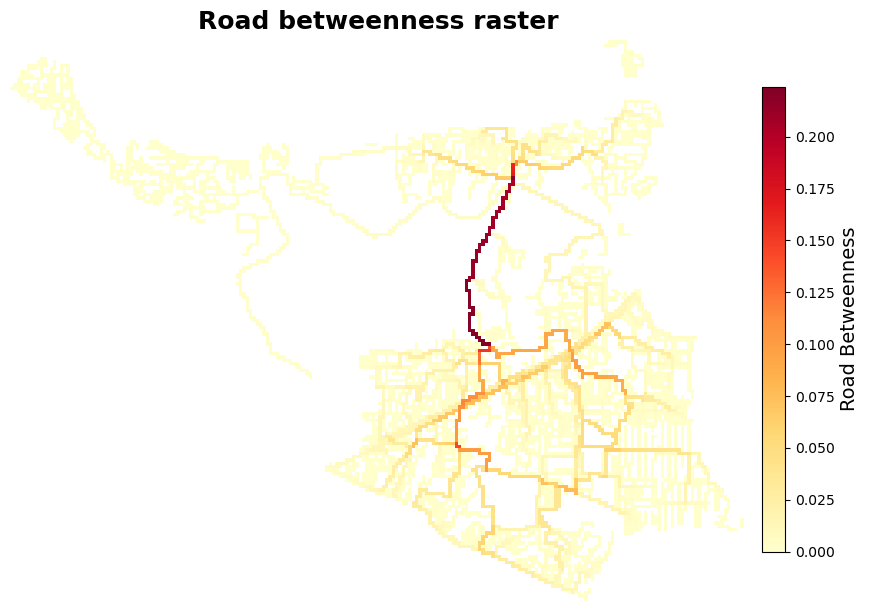

In [79]:
# Assume betweenness_raster is your NumPy array
# Mask NaNs so they appear transparent
masked = np.ma.masked_invalid(betweenness_raster)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(
    masked,
    cmap="YlOrRd",   # or "Spectral_r", "hot"
    origin="upper"
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Road Betweenness", fontsize=14)

ax.set_title("Road betweenness raster", fontsize=18, fontweight="bold")
ax.axis("off")
plt.savefig(raster_betweeness_img_path, dpi=300, bbox_inches='tight')
plt.show()


In [80]:
## Export this to a .tif file to check in QGIS
betweenness_raster_path = PROCESSED_DIR / 'betweeness_raster_bellandur.tif'

# Update metadata for single-band raster above
meta.update({
    "dtype": "float32",
    "count": 1,
    "nodata": np.nan
})

# Write raster
with rasterio.open(betweenness_raster_path, "w", **meta) as dst:
    dst.write(betweenness_raster, 1)


Extract the LST raster and this only for the road pixels and plot: 

In [81]:
raster_lst_betweeness_img_path = IMAGES_DIR / 'LST_roads_raster_bellandur.png'

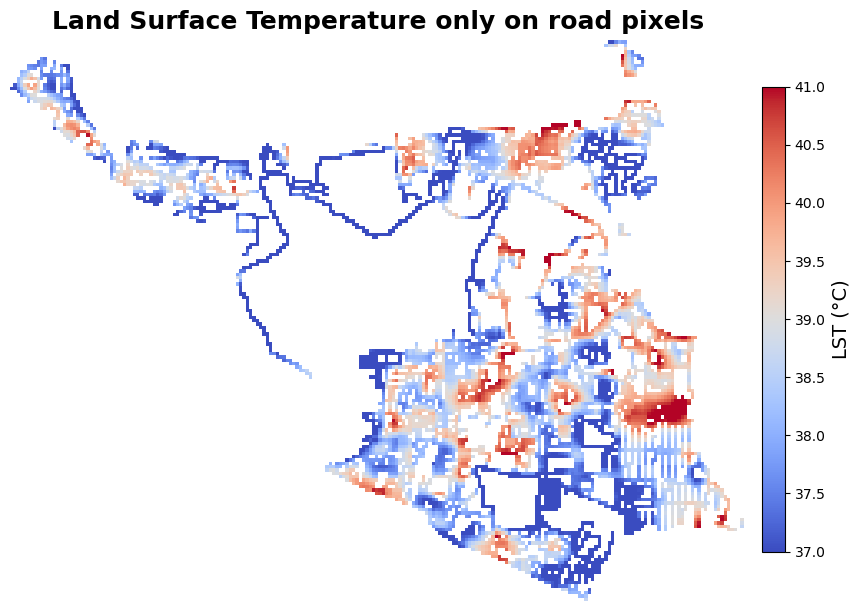

In [82]:
with rasterio.open(filepath) as src:
    lst = src.read(1).astype("float32")

# Mask NoData in LST
lst_masked = np.ma.masked_invalid(lst)

bet_masked = np.ma.masked_invalid(betweenness_raster)

lst_masked_for_roads = np.ma.masked_where(np.isnan(betweenness_raster), lst_masked)

fig, ax = plt.subplots(figsize=(10, 10))

vmin = 37
vmax = 41

im = ax.imshow(
    lst_masked_for_roads,
    cmap="coolwarm",  # LST color map
    origin="upper",
    vmin = vmin,
    vmax = vmax
)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("LST (°C)", fontsize=14)

ax.set_title("Land Surface Temperature only on road pixels", fontsize=18, fontweight="bold")
ax.axis("off")
plt.savefig(raster_lst_betweeness_img_path, dpi=300, bbox_inches='tight')
plt.show()

Overlay the two rasters (LST raster with LST pixelised betweenness centrality):

CODE TO DO

For the time being, the visualisation has happened in QGIS.

## Regression and correlation analysis

In [83]:
lst_flat = lst_masked_for_roads.flatten()
bet_flat = betweenness_raster.flatten()

In [84]:
mask = (~np.isnan(lst_flat)) & (~np.isnan(bet_flat))

In [85]:
lst_valid = lst_flat[mask]
bet_valid = bet_flat[mask]
df = pd.DataFrame({
    "LST": lst_valid,
    "betweenness": bet_valid
})

df[0:-10]

,LST,betweenness
0,36.982300,0.000011
1,36.982300,0.000011
2,37.549690,0.000011
3,38.023087,0.000011
4,37.831676,0.000011
...,...,...
6825,38.751125,0.015186
6826,37.859020,0.015186
6827,37.932507,0.015186
6828,37.932507,0.012266


In [86]:
df.describe()

,LST,betweenness
count,6840.000000,6840.000000
mean,38.162563,0.011607
std,2.059293,0.028861
min,0.000000,0.000000
25%,37.293339,0.000395
50%,38.357197,0.000745
75%,39.286045,0.007776
max,42.336628,0.224111


In [87]:
## Remove outliers
df_clean = df[(df["LST"] != 0) & (df["betweenness"] != 0)]

In [88]:
df_clean.describe()

,LST,betweenness
count,6302.000000,6.302000e+03
mean,38.253895,1.259634e-02
std,1.528260,2.986006e-02
min,30.834990,2.613176e-07
25%,37.348026,6.182775e-04
50%,38.419575,1.236032e-03
75%,39.316807,1.068083e-02
max,42.336628,2.241115e-01


In [89]:
pearsonr(df_clean['LST'], df_clean['betweenness'])

PearsonRResult(statistic=np.float32(-0.08012787), pvalue=np.float64(1.8910063971350554e-10))

In [90]:
fig_path = IMAGES_DIR / 'regression_lst_betweenness_bellandur.png'

In [91]:
x = df_clean['betweenness']
y = df_clean['LST']

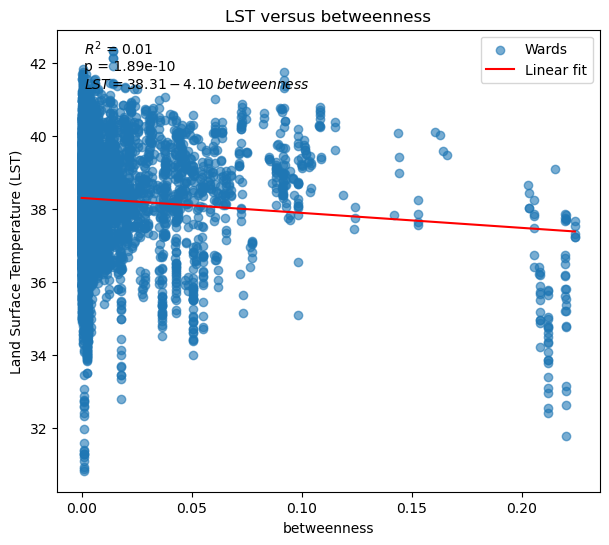

In [92]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("betweenness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus betweenness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} {slope:.2f}\\,betweenness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()